In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")


import bessel_test as BT

import analytic_test as AT

import analytic_test_gaunt as ATG

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


# Testing the different methods of obtaining acceleration from density field

## 1) Static cNFWt Profile using Bessel

In [22]:

import importlib
importlib.reload(BT)


animate = False
static = True
frozen = False

cNFWt_test = BT.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, N_max = 1000, static = static, frozen = frozen, animate=animate, animate_every=10)

[CudaDevice(id=0)]


l max from jaxsp: 23
Forward s2fft completed in 0.01 seconds


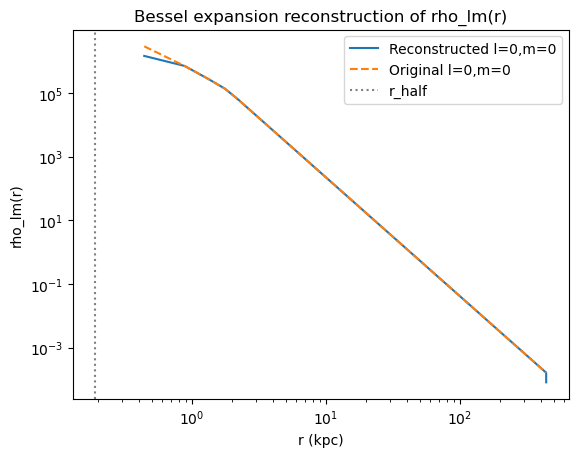

Conversion from rho_lm(r) to rho_nlm completed in 1.65 seconds
Time step 2 / 1000
Time stepping particle completed in 3.19 seconds
Time step 3 / 1000
Time stepping particle completed in 3.53 seconds
Time step 4 / 1000
Time stepping particle completed in 3.34 seconds
Time step 5 / 1000
Time stepping particle completed in 3.26 seconds
Time step 6 / 1000
Time stepping particle completed in 3.40 seconds
Time step 7 / 1000
Time stepping particle completed in 3.40 seconds
Time step 8 / 1000
Time stepping particle completed in 3.07 seconds
Time step 9 / 1000
Time stepping particle completed in 3.89 seconds
Time step 10 / 1000
Time stepping particle completed in 3.19 seconds
Time step 11 / 1000
Time stepping particle completed in 3.08 seconds
Time step 12 / 1000
Time stepping particle completed in 3.44 seconds
Time step 13 / 1000
Time stepping particle completed in 3.05 seconds
Time step 14 / 1000
Time stepping particle completed in 3.38 seconds
Time step 15 / 1000
Time stepping particle compl

KeyboardInterrupt: 

In [23]:
cNFWt_test.run_simulation()

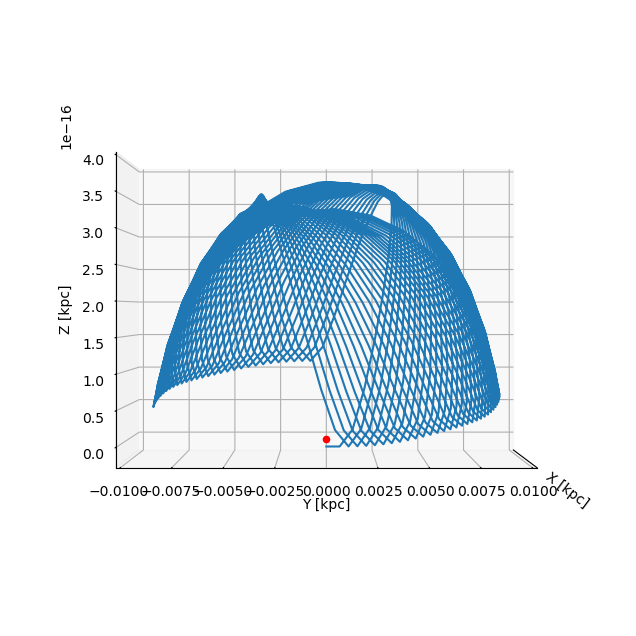

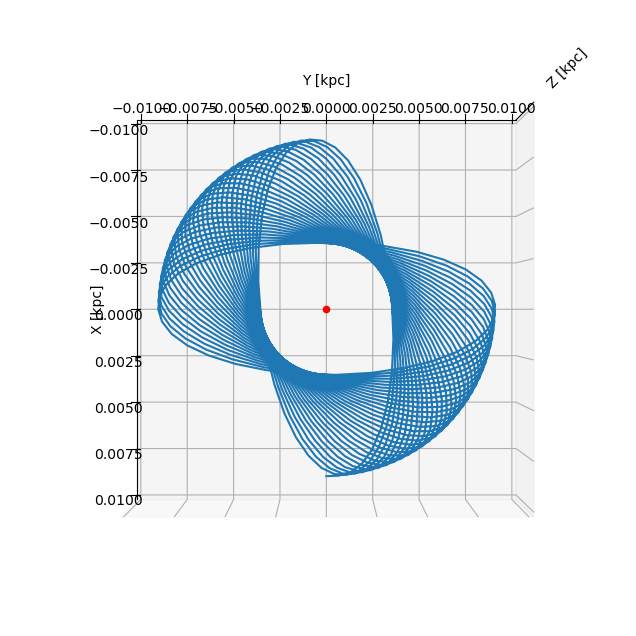

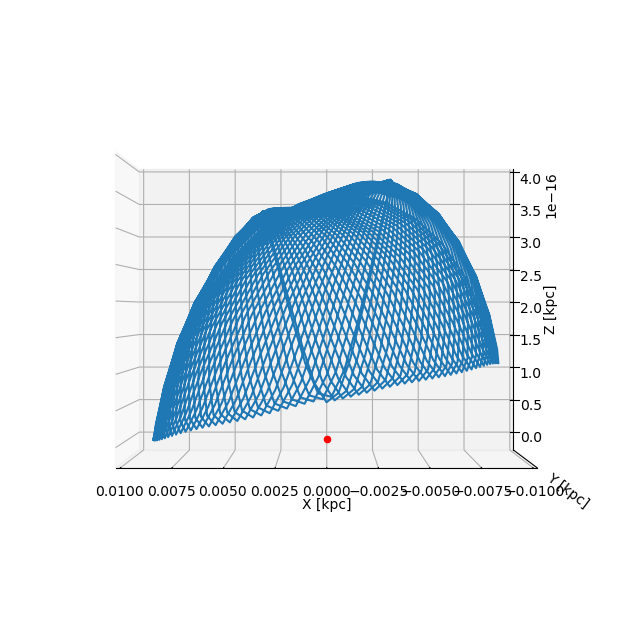

In [12]:
pos = np.array(cNFWt_test.positions_xyz)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


KeyboardInterrupt: 

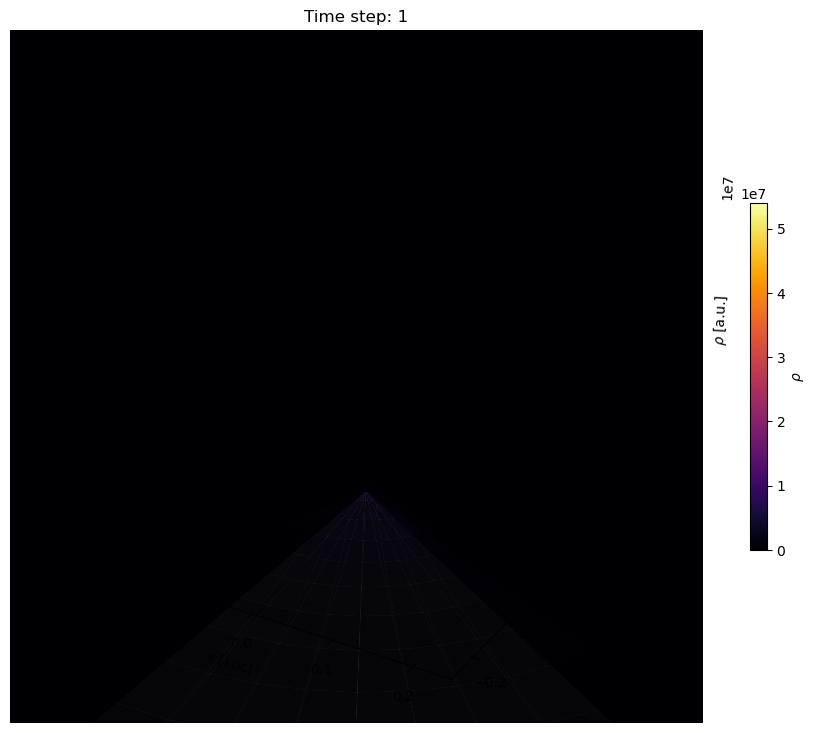

In [13]:
if animate == True:
    ani = cNFWt_test.animator.create_animation()


In [6]:

velocities = np.array(cNFWt_test.velocities)
stellar_v_disp = np.array(cNFWt_test.stellar_v_disp) 
average_r = np.array(cNFWt_test.average_r)
r_values = np.array(cNFWt_test.r_values)
time_step = cNFWt_test.time_step

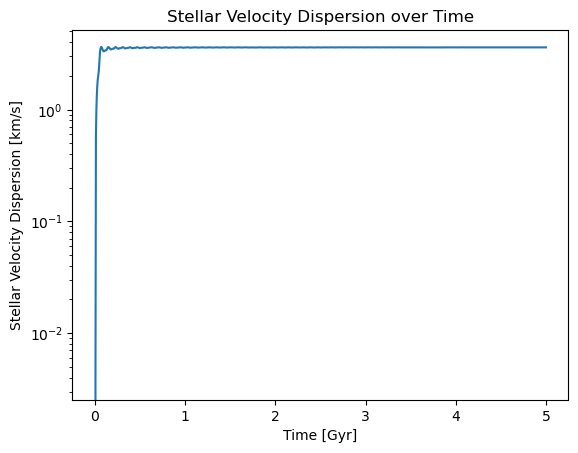

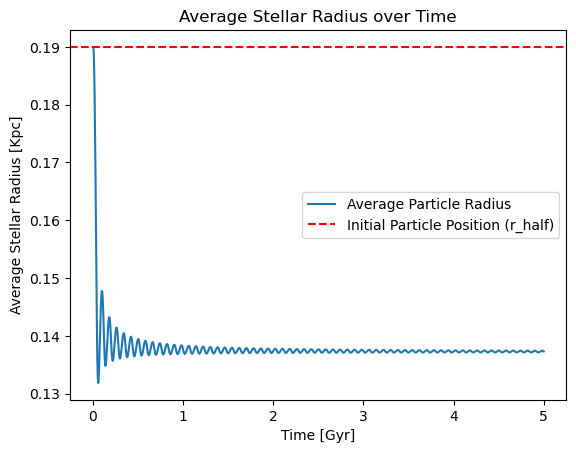

In [7]:


x = np.linspace(0, time_step, len(stellar_v_disp))

plt.plot(x * cNFWt_test.dt * cNFWt_test.u.to_Gyr, stellar_v_disp * cNFWt_test.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * cNFWt_test.dt * cNFWt_test.u.to_Gyr, average_r * cNFWt_test.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, r_values * first_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(cNFWt_test.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

## 2) Frozen ULDM profile using Analytic

In [2]:

import importlib
importlib.reload(ATG)


animate = False
static = False
frozen = True

frozen_test_analytic = ATG.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, static = static, frozen = frozen, animate=animate, animate_every=10)

[CudaDevice(id=0)]


In [3]:

frozen_test_analytic.run_simulation()

l max from jaxsp: 23


W0318 11:48:39.043873 1716199 cuda_command_buffer.cc:768] Retry CUDA graph instantiation after OOM error
E0318 11:48:39.044209 1716199 pjrt_stream_executor_client.cc:2091] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 100 (total of 25 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory


ValueError: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 100 (total of 25 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory

(1001, 3)


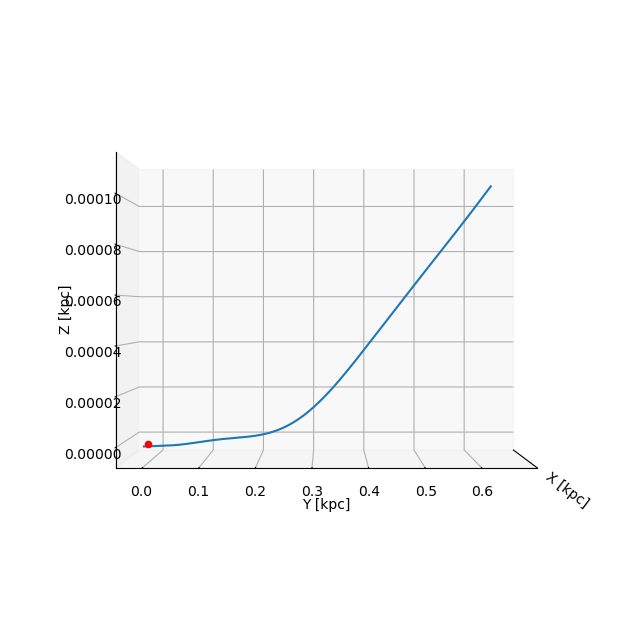

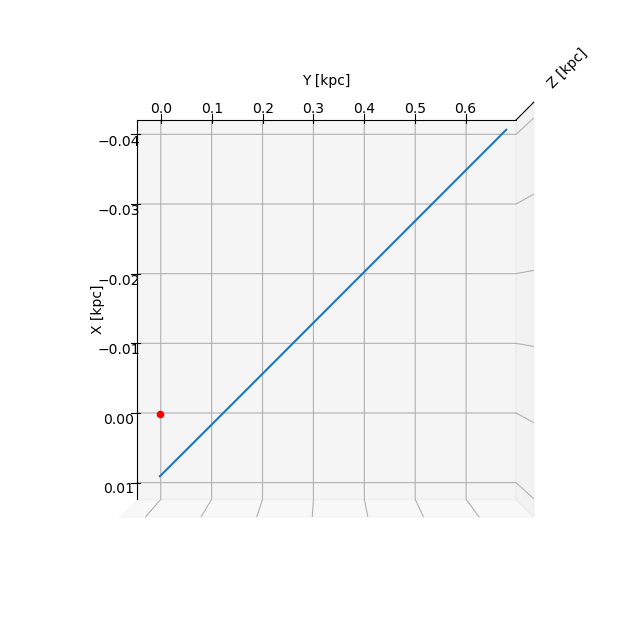

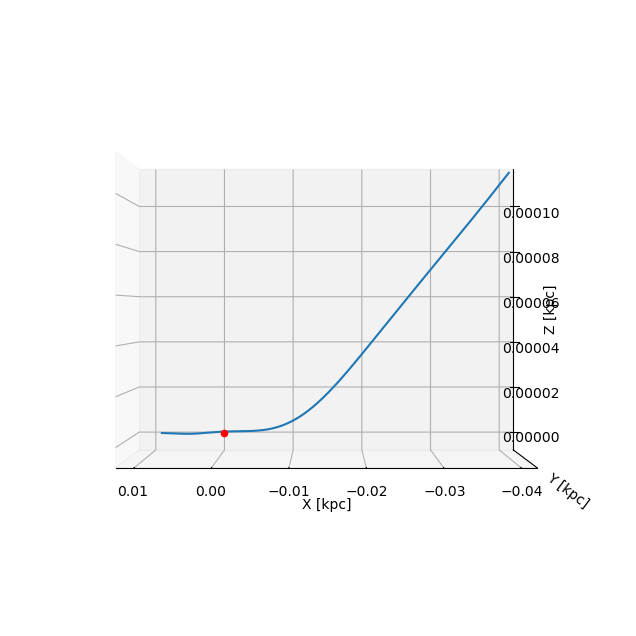

In [5]:
pos2 = np.array(frozen_test_analytic.positions_xyz)
print(pos2.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos2[:, 0], pos2[:, 1], pos2[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos2[:, 0], pos2[:, 1], pos2[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos2[:, 0], pos2[:, 1], pos2[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [6]:
if animate == True:
    ani = frozen_test_analytic.animator.create_animation()


In [7]:

velocities2 = np.array(frozen_test_analytic.velocities)
stellar_v_disp2 = np.array(frozen_test_analytic.stellar_v_disp) 
average_r2 = np.array(frozen_test_analytic.average_r)
r_values2 = np.array(frozen_test_analytic.r_values)
time_step2 = frozen_test_analytic.time_step

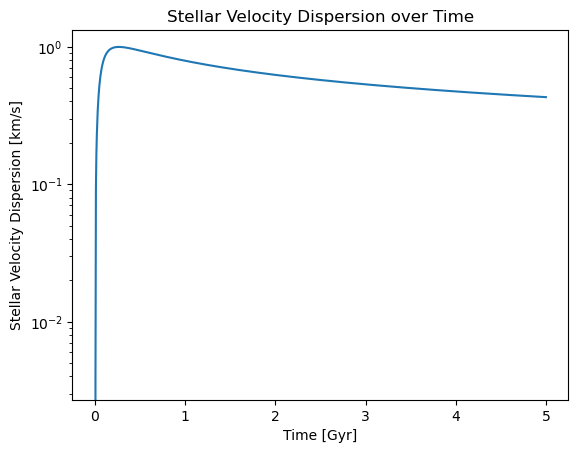

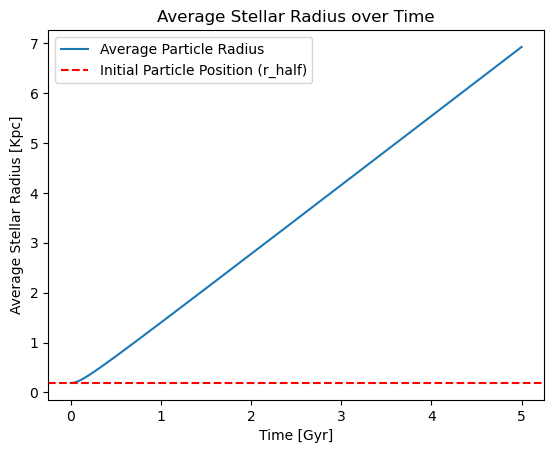

In [8]:


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, stellar_v_disp2 * frozen_test_analytic.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, average_r2 * frozen_test_analytic.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, r_values * first_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(frozen_test_analytic.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()